# Session 15 Worksheet: Derivatives & Gradients

## Objective:
To understand the concept of derivatives and gradients by differentiating a cost function and visualizing the process of gradient descent.

---

## Background Theory:
In machine learning, **derivatives** represent how a function changes with respect to its inputs.  
The **gradient** is a vector of partial derivatives that points in the direction of the steepest increase of a function.  
**Gradient descent** is an optimization algorithm used to minimize a cost function by iteratively moving in the direction of the steepest descent.

---

## Activity Instructions:

1. **Define a simple quadratic cost function**:  
   \( f(x) = (x – 3)^2 + 4 \)

2. **Compute the derivative (gradient) of the function analytically**:  
   \( f'(x) = 2(x - 3) \)

3. **Visualize the function and its gradient using Python**.

4. **Perform gradient descent** starting from an initial guess (e.g., \( x = 0 \)).

5. **Observe** how the value of \( x \) moves towards the minimum and how the gradient decreases.


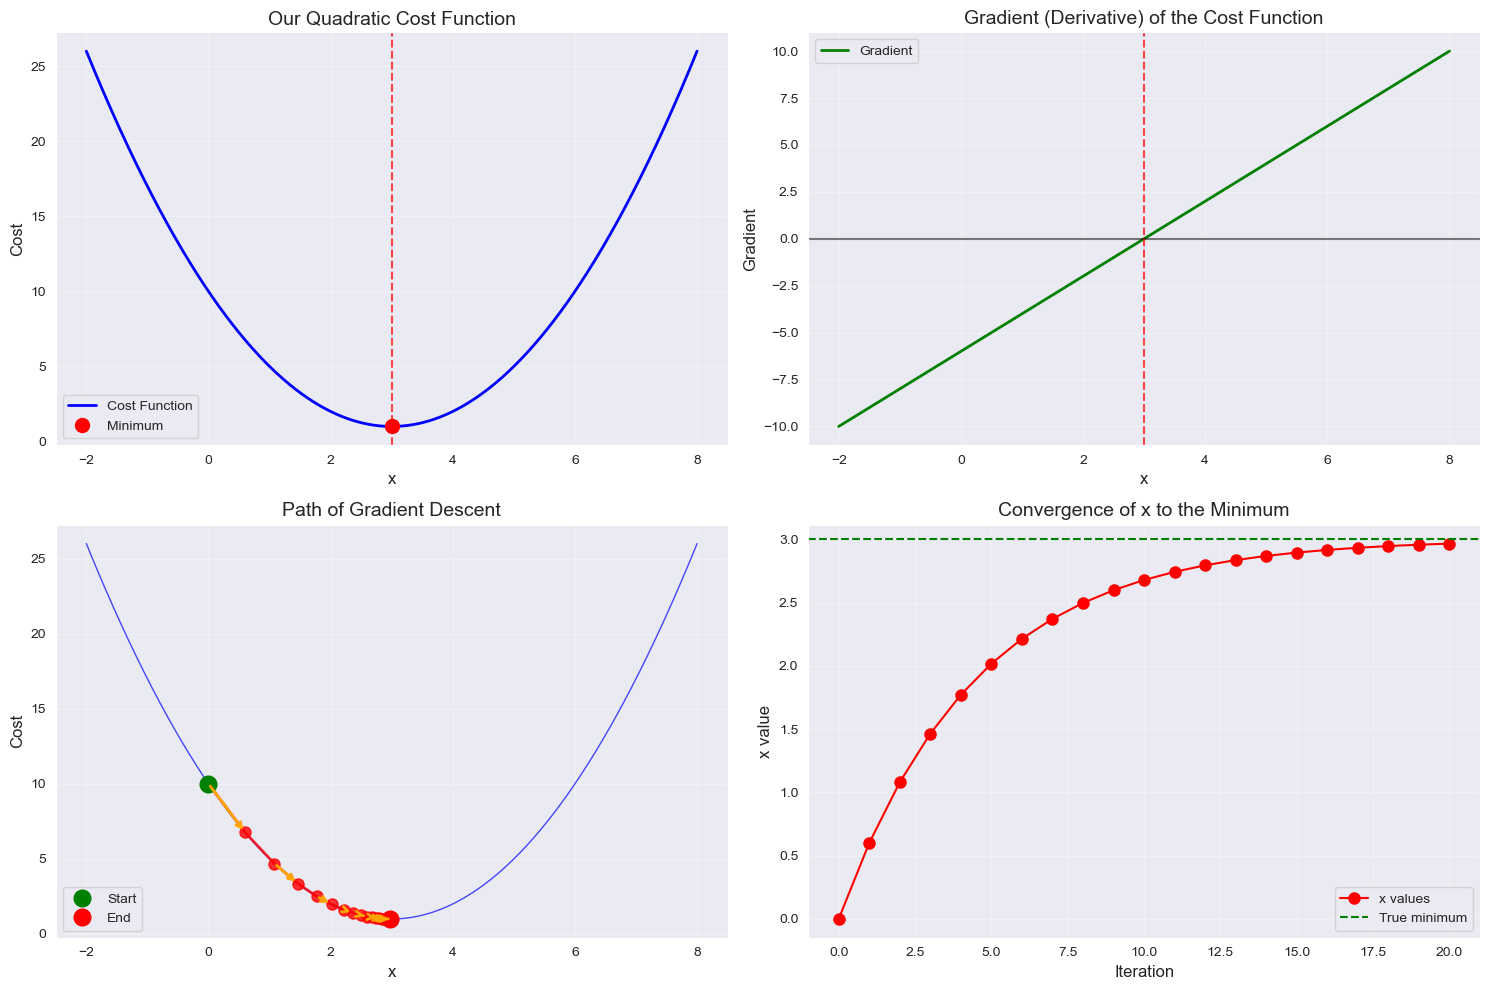

Gradient Descent Results:
--------------------------------------------------
Starting point: x = 0
True minimum: x = 3
Found minimum: x = 2.965412
Error: 0.034588
Final cost: 1.001196
Final gradient: -0.069175

Iteration-by-iteration breakdown:
--------------------------------------------------
Iter | x value  | Cost     | Gradient
--------------------------------------------------
   0 |   0.0000 |  10.0000 |  -6.0000
   1 |   0.6000 |   6.7600 |  -4.8000
   2 |   1.0800 |   4.6864 |  -3.8400
   3 |   1.4640 |   3.3593 |  -3.0720
   4 |   1.7712 |   2.5099 |  -2.4576
   5 |   2.0170 |   1.9664 |  -1.9661
   6 |   2.2136 |   1.6185 |  -1.5729
   7 |   2.3709 |   1.3958 |  -1.2583
   8 |   2.4967 |   1.2533 |  -1.0066
   9 |   2.5973 |   1.1621 |  -0.8053
...
  20 |   2.9654 |   1.0012 |  -0.0692


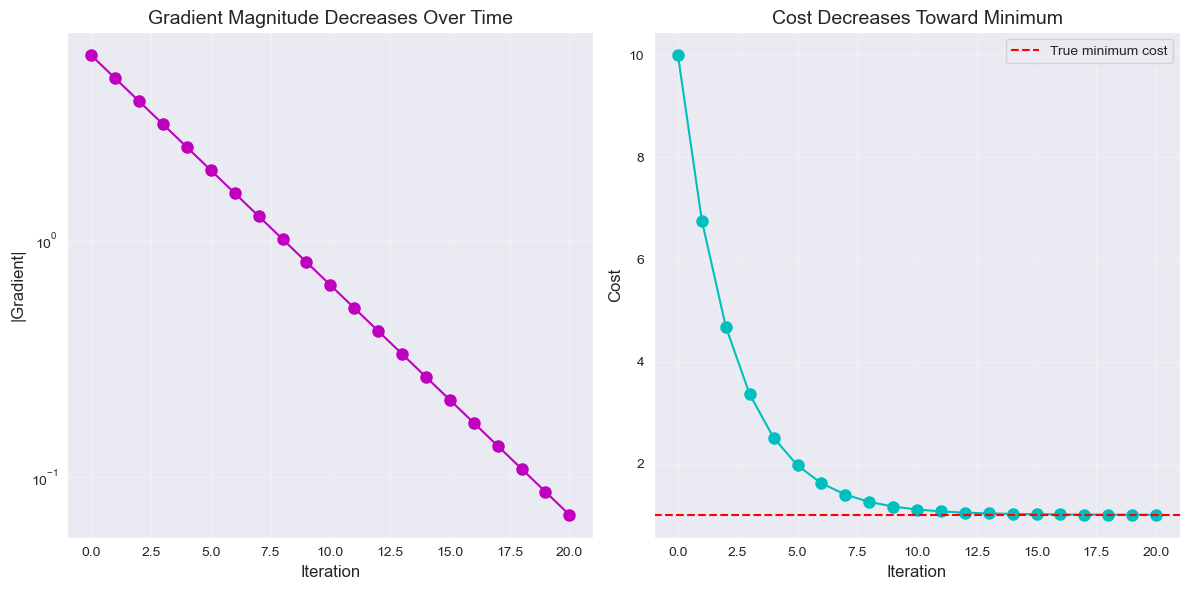


Experiment: Different Learning Rates
--------------------------------------------------


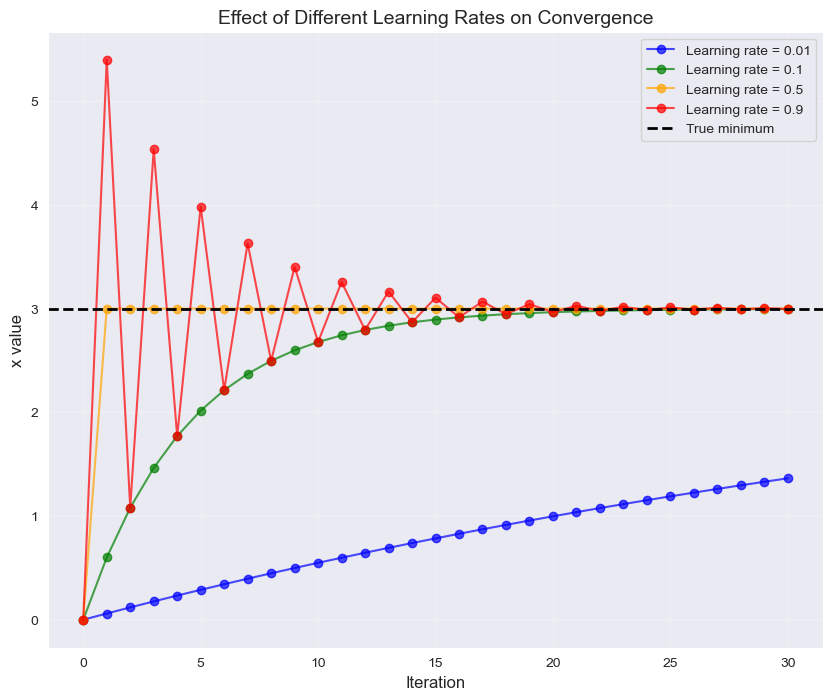

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define our quadratic cost function
# Think of this as the error landscape we want to navigate
def cost_function(x):
    """
    A simple quadratic cost function: f(x) = (x - 3)^2 + 1
    
    This represents a parabola with:
    - Minimum at x = 3 (where the cost is 1)
    - The shape of a bowl, encouraging us to "roll" toward the center
    """
    return (x - 3)**2 + 1

# Step 2: Compute the analytical derivative (gradient)
# This tells us which direction to move to decrease the cost
def gradient(x):
    """
    The derivative of our cost function: f'(x) = 2(x - 3)
    
    Think of this as the "steepness" at any point:
    - Positive values mean the function is increasing (we should go left)
    - Negative values mean the function is decreasing (we should go right)
    - Zero means we're at the bottom!
    """
    return 2 * (x - 3)

# Step 3: Visualize the function and its gradient
plt.figure(figsize=(15, 10))

# Create a range of x values for plotting
x_values = np.linspace(-2, 8, 1000)
y_values = cost_function(x_values)
gradient_values = gradient(x_values)

# Plot 1: The cost function itself
plt.subplot(2, 2, 1)
plt.plot(x_values, y_values, 'b-', linewidth=2, label='Cost Function')
plt.plot(3, cost_function(3), 'ro', markersize=10, label='Minimum')
plt.axvline(x=3, color='r', linestyle='--', alpha=0.7)
plt.xlabel('x', fontsize=12)
plt.ylabel('Cost', fontsize=12)
plt.title('Our Quadratic Cost Function', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: The gradient (derivative) function
plt.subplot(2, 2, 2)
plt.plot(x_values, gradient_values, 'g-', linewidth=2, label='Gradient')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.5)
plt.axvline(x=3, color='r', linestyle='--', alpha=0.7)
plt.xlabel('x', fontsize=12)
plt.ylabel('Gradient', fontsize=12)
plt.title('Gradient (Derivative) of the Cost Function', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Step 4: Implement gradient descent
def gradient_descent(starting_point, learning_rate, num_iterations):
    """
    Perform gradient descent to find the minimum of our cost function
    
    Parameters:
    - starting_point: Where we begin our search
    - learning_rate: How big steps we take (like stride length)
    - num_iterations: How many steps we'll take
    """
    # Track our journey
    x_history = [starting_point]
    cost_history = [cost_function(starting_point)]
    gradient_history = [gradient(starting_point)]
    
    current_x = starting_point
    
    # Take each step of our descent
    for i in range(num_iterations):
        # Calculate the gradient at our current position
        grad = gradient(current_x)
        
        # Move in the opposite direction of the gradient
        # (opposite because we want to go downhill)
        current_x = current_x - learning_rate * grad
        
        # Record our progress
        x_history.append(current_x)
        cost_history.append(cost_function(current_x))
        gradient_history.append(gradient(current_x))
    
    return x_history, cost_history, gradient_history

# Step 5: Run gradient descent and visualize the process
starting_point = 0  # Starting from the left side
learning_rate = 0.1  # Not too big, not too small
num_iterations = 20

x_history, cost_history, gradient_history = gradient_descent(
    starting_point, learning_rate, num_iterations
)

# Plot 3: Visualize the path of gradient descent
plt.subplot(2, 2, 3)
plt.plot(x_values, y_values, 'b-', linewidth=1, alpha=0.7)
plt.plot(x_history, cost_history, 'ro-', markersize=8, linewidth=2, alpha=0.8)
plt.plot(x_history[0], cost_history[0], 'go', markersize=12, label='Start')
plt.plot(x_history[-1], cost_history[-1], 'ro', markersize=12, label='End')

# Add arrows to show the direction of movement
for i in range(0, len(x_history)-1, 2):
    plt.annotate('', xy=(x_history[i+1], cost_history[i+1]), 
                xytext=(x_history[i], cost_history[i]),
                arrowprops=dict(arrowstyle='->', color='orange', lw=2))

plt.xlabel('x', fontsize=12)
plt.ylabel('Cost', fontsize=12)
plt.title('Path of Gradient Descent', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: Show how x converges to the minimum
plt.subplot(2, 2, 4)
iterations = range(len(x_history))
plt.plot(iterations, x_history, 'ro-', markersize=8, label='x values')
plt.axhline(y=3, color='g', linestyle='--', label='True minimum')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('x value', fontsize=12)
plt.title('Convergence of x to the Minimum', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed results
print("Gradient Descent Results:")
print("-" * 50)
print(f"Starting point: x = {starting_point}")
print(f"True minimum: x = 3")
print(f"Found minimum: x = {x_history[-1]:.6f}")
print(f"Error: {abs(3 - x_history[-1]):.6f}")
print(f"Final cost: {cost_history[-1]:.6f}")
print(f"Final gradient: {gradient_history[-1]:.6f}")
print("\nIteration-by-iteration breakdown:")
print("-" * 50)
print("Iter | x value  | Cost     | Gradient")
print("-" * 50)
for i in range(min(10, len(x_history))):  # Show first 10 iterations
    print(f"{i:4d} | {x_history[i]:8.4f} | {cost_history[i]:8.4f} | {gradient_history[i]:8.4f}")
if len(x_history) > 10:
    print("...")
    i = len(x_history) - 1
    print(f"{i:4d} | {x_history[i]:8.4f} | {cost_history[i]:8.4f} | {gradient_history[i]:8.4f}")

# Let's also create a second visualization showing gradient magnitude
plt.figure(figsize=(12, 6))

# Plot the gradient magnitude over iterations
plt.subplot(1, 2, 1)
gradient_magnitudes = [abs(g) for g in gradient_history]
plt.plot(range(len(gradient_magnitudes)), gradient_magnitudes, 'mo-', markersize=8)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('|Gradient|', fontsize=12)
plt.title('Gradient Magnitude Decreases Over Time', fontsize=14)
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Logarithmic scale to see the exponential decay

# Plot the cost reduction over iterations
plt.subplot(1, 2, 2)
plt.plot(range(len(cost_history)), cost_history, 'co-', markersize=8)
plt.axhline(y=1, color='r', linestyle='--', label='True minimum cost')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost', fontsize=12)
plt.title('Cost Decreases Toward Minimum', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Experiment with different learning rates
print("\nExperiment: Different Learning Rates")
print("-" * 50)
learning_rates = [0.01, 0.1, 0.5, 0.9]
colors = ['blue', 'green', 'orange', 'red']

plt.figure(figsize=(10, 8))
for lr, color in zip(learning_rates, colors):
    x_hist, cost_hist, _ = gradient_descent(0, lr, 30)
    plt.plot(range(len(x_hist)), x_hist, 'o-', color=color, alpha=0.7, 
             label=f'Learning rate = {lr}', markersize=6)

plt.axhline(y=3, color='black', linestyle='--', linewidth=2, label='True minimum')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('x value', fontsize=12)
plt.title('Effect of Different Learning Rates on Convergence', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Gradient Descent: Step-by-Step Breakdown

## Step 1: Understanding Our Cost Function

Think of our cost function like a landscape. We've chosen a simple quadratic function:  
**f(x) = (x - 3)² + 1**

This creates a perfect bowl shape with:

- The bottom (minimum) at **x = 3**
- The minimum cost value of **1**
- Smooth, predictable slopes on both sides

> In real machine learning, this cost function might represent how "wrong" our model's predictions are.  
> Our goal is to find the x value that minimizes this wrongness.

---

## Step 2: The Derivative - Our Compass

The derivative:  
**f′(x) = 2(x - 3)**  
It acts like a **compass pointing in the direction of steepest ascent**. This is crucial because:

- **x < 3**: The derivative is negative (function is decreasing to the right)
- **x > 3**: The derivative is positive (function is increasing to the right)
- **x = 3**: The derivative is zero (we've found the minimum!)

> Think of standing on a hillside: the derivative tells you which way tilts upward.  
> To go downhill, we walk in the **opposite direction**.

---

## Step 3: Visualizing the Landscape

The visualization code creates four key plots:

1. **The cost function**: Shows our "error landscape"
2. **The gradient function**: Shows which direction is uphill at each point
3. **The descent path**: Shows how we navigate toward the minimum
4. **Convergence plot**: Shows how x approaches the true minimum

---

## Step 4: The Heart of Gradient Descent

Here's where the magic happens. Our algorithm works like this:

```python
current_x = current_x - learning_rate * gradient(current_x)
```

This simple line implements three key ideas:

1. **Calculate the gradient**: How steep is the hill at my current position?
2. **Choose direction**: Go opposite to the gradient (downhill)
3. **Take a step**: Move a distance proportional to our learning rate

---

## Step 5: Watching the Algorithm Learn

As you run the code, notice several fascinating patterns:

- **Exponential convergence**: The x value quickly approaches 3
- **Shrinking gradients**: As we near the minimum, the gradient approaches zero
- **Overshooting**: Sometimes we step past the minimum but gradually zero in

---

## The Learning Rate - A Critical Parameter

The learning rate acts like your stride length when hiking:

- **Too small**: You take forever to reach the bottom
- **Too large**: You might leap right over the minimum or oscillate wildly
- **Just right**: You reach the minimum efficiently

---

## Why This Matters in Machine Learning

This simple example contains the essence of how neural networks learn:

- We **define a cost** that measures prediction error
- We **calculate gradients** to find which direction reduces error
- We **incrementally adjust parameters** to minimize that error


Run the code and then modify:
* The starting point (try x = 10)
* The learning rate (try 0.01 vs 0.9)
* The number of iterations
Watch how these changes affect convergence. This hands-on experimentation will deepen your understanding of how gradient descent behavior changes with different parameters.

EXPERIMENT 1: How does the starting point affect convergence?

Think of this as asking: 'Does it matter where I begin my hike down the mountain?'
Intuition: Starting farther from the minimum should take longer to converge.

Testing starting point: x = 0


<Figure size 1500x800 with 0 Axes>

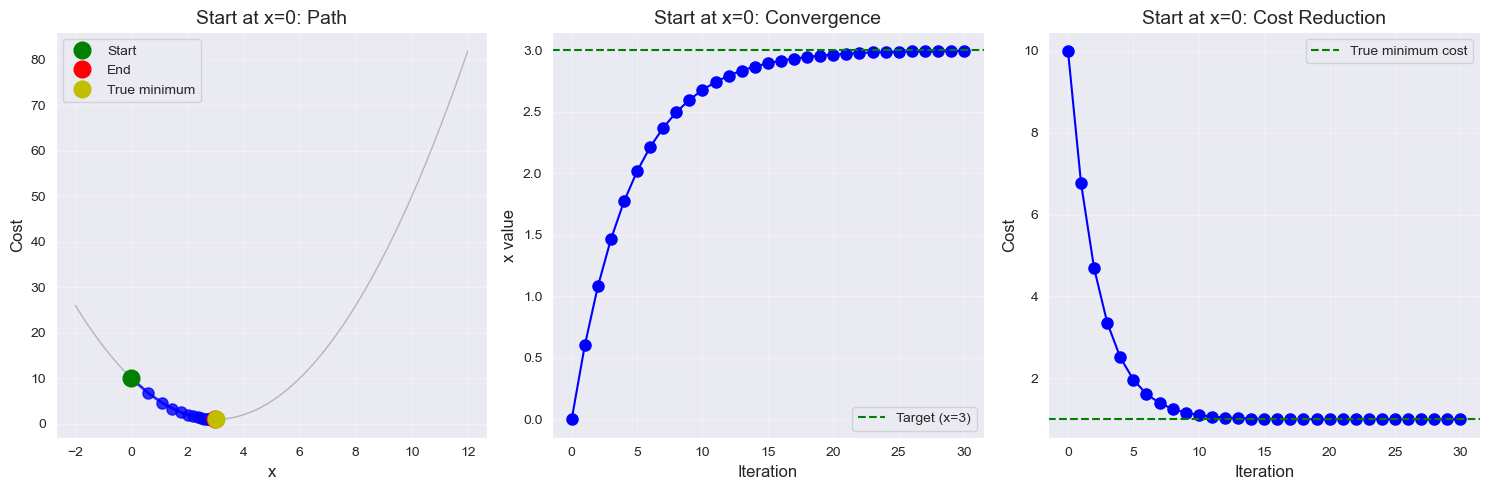


Start at x=0 - Analysis:
--------------------------------------------------
Starting point: x = 0
Final position: x = 2.996286
Distance to true minimum: 0.003714
Starting cost: 10.000000
Final cost: 1.000014
Cost reduction: 8.999986
--------------------------------------------------

Testing starting point: x = 5


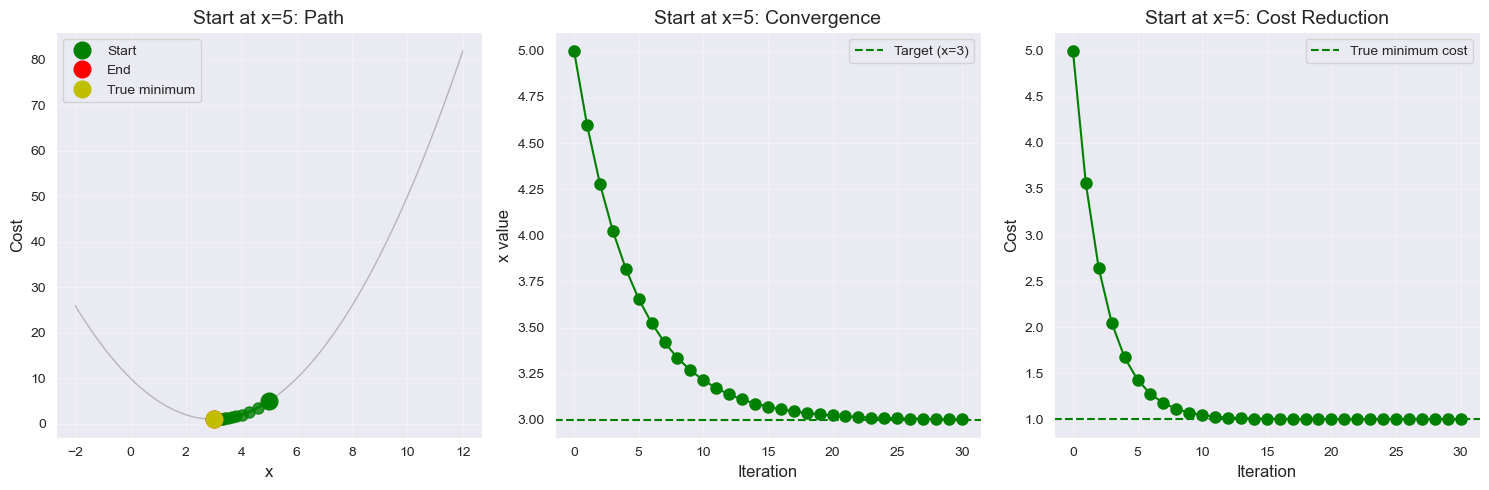


Start at x=5 - Analysis:
--------------------------------------------------
Starting point: x = 5
Final position: x = 3.002476
Distance to true minimum: 0.002476
Starting cost: 5.000000
Final cost: 1.000006
Cost reduction: 3.999994
--------------------------------------------------

Testing starting point: x = 10


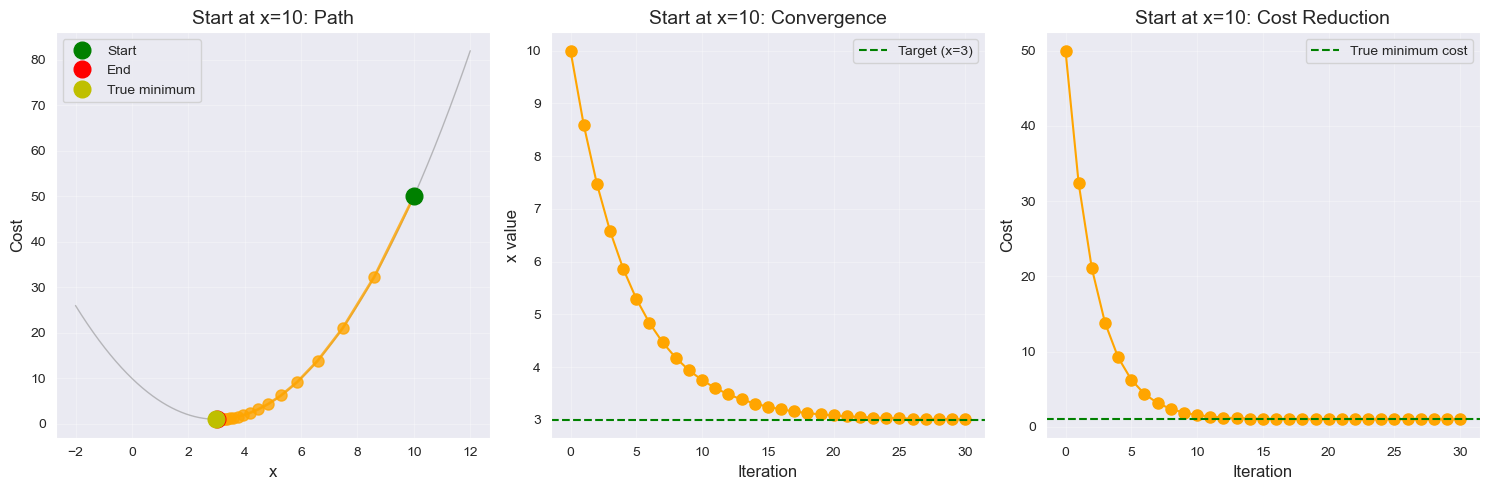


Start at x=10 - Analysis:
--------------------------------------------------
Starting point: x = 10
Final position: x = 3.008666
Distance to true minimum: 0.008666
Starting cost: 50.000000
Final cost: 1.000075
Cost reduction: 48.999925
--------------------------------------------------

Testing starting point: x = -5


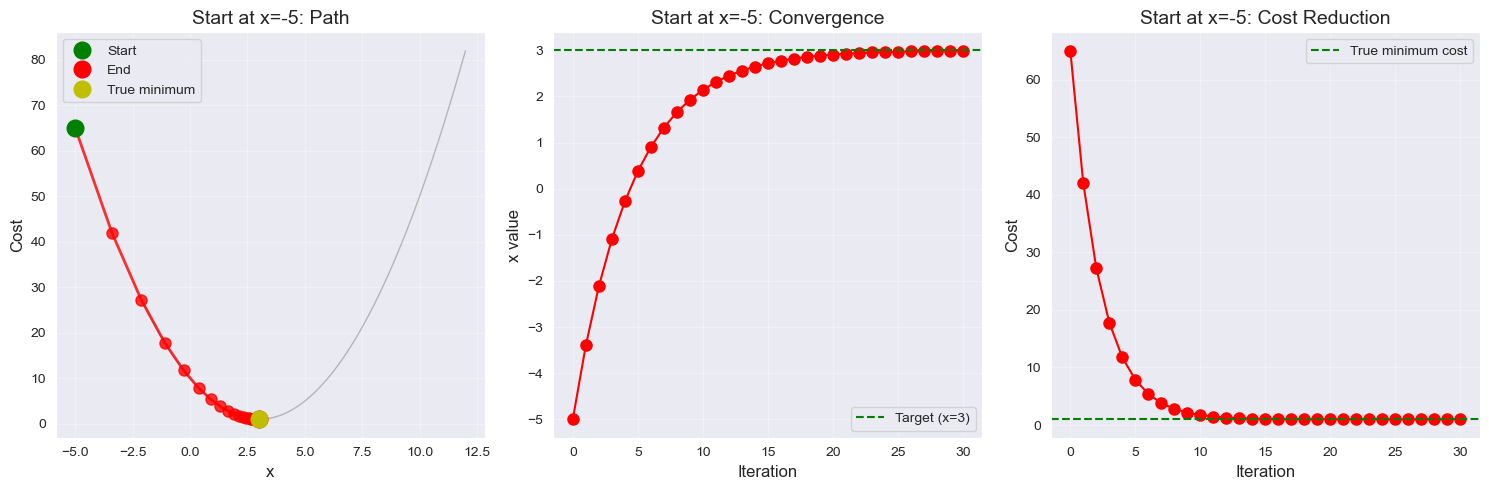


Start at x=-5 - Analysis:
--------------------------------------------------
Starting point: x = -5
Final position: x = 2.990096
Distance to true minimum: 0.009904
Starting cost: 65.000000
Final cost: 1.000098
Cost reduction: 63.999902
--------------------------------------------------


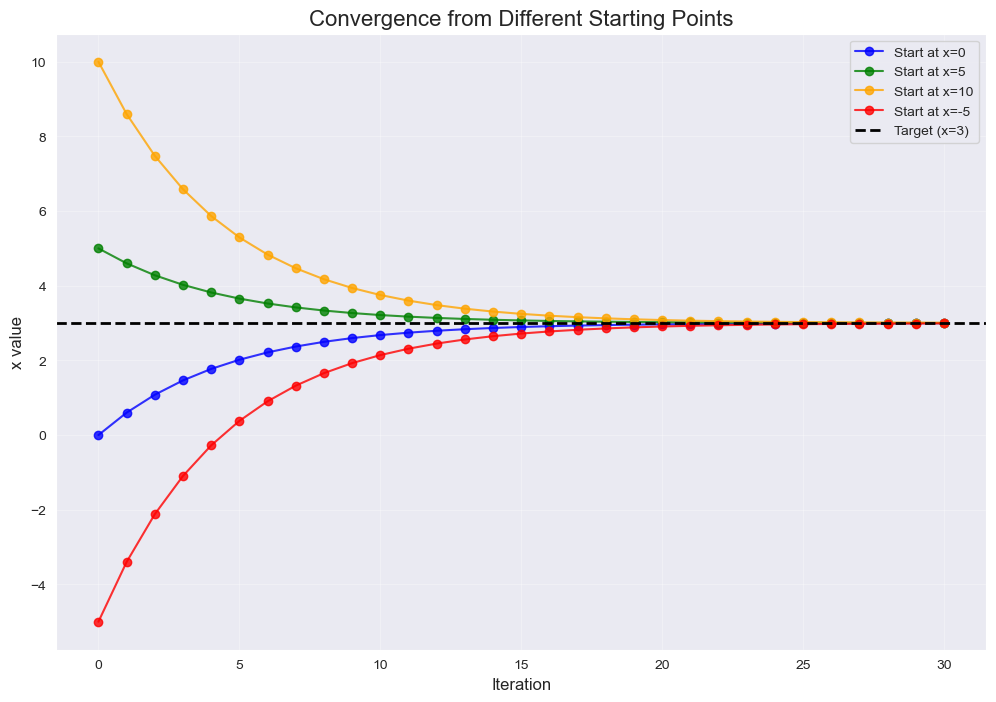


EXPERIMENT 2: How does the learning rate affect convergence?

Think of this as asking: 'What happens if I take bigger or smaller steps?'
Intuition: Too small steps = slow progress, too large steps = overshooting

Testing learning rate: 0.01


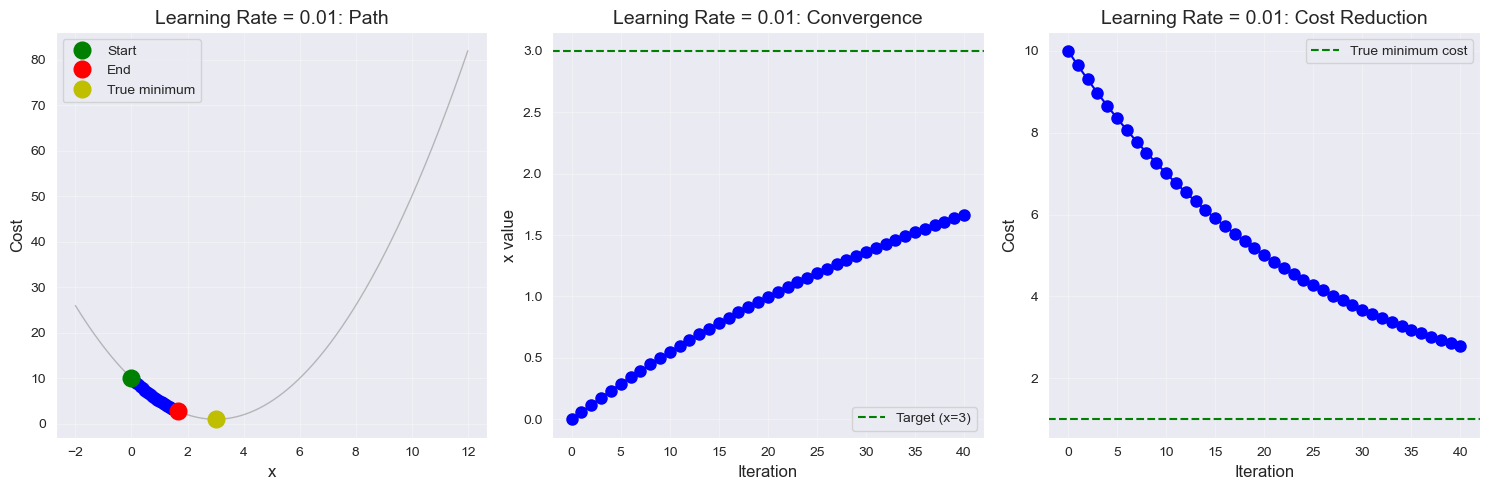


Learning Rate = 0.01 - Analysis:
--------------------------------------------------
Starting point: x = 0
Final position: x = 1.662899
Distance to true minimum: 1.337101
Starting cost: 10.000000
Final cost: 2.787840
Cost reduction: 7.212160
--------------------------------------------------

Testing learning rate: 0.1


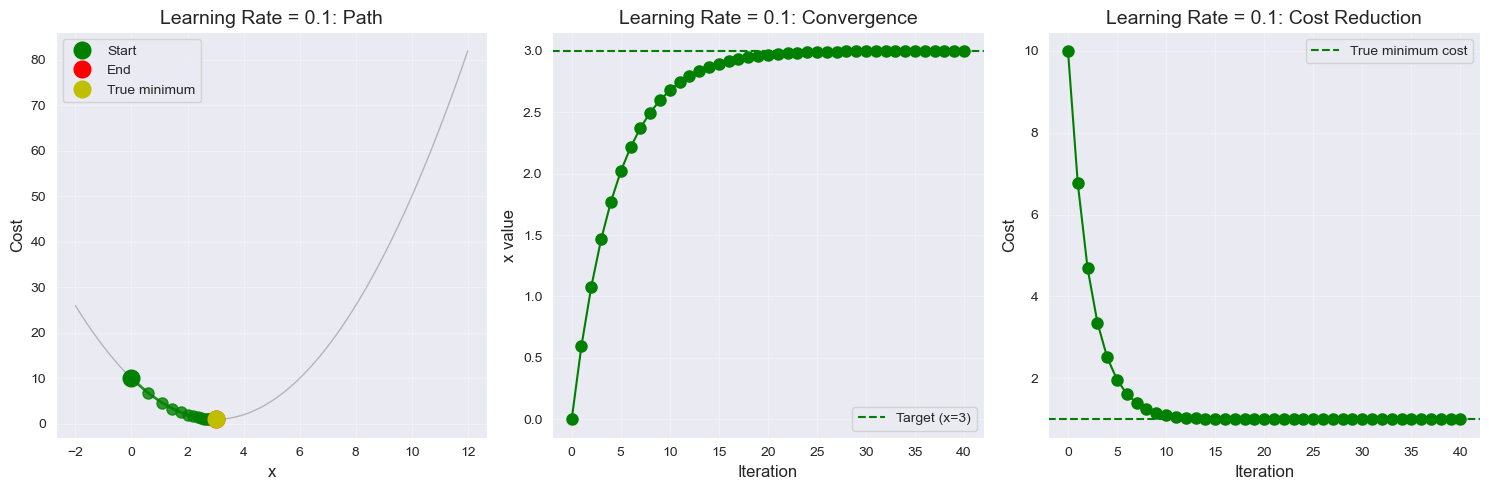


Learning Rate = 0.1 - Analysis:
--------------------------------------------------
Starting point: x = 0
Final position: x = 2.999601
Distance to true minimum: 0.000399
Starting cost: 10.000000
Final cost: 1.000000
Cost reduction: 9.000000
--------------------------------------------------

Testing learning rate: 0.5


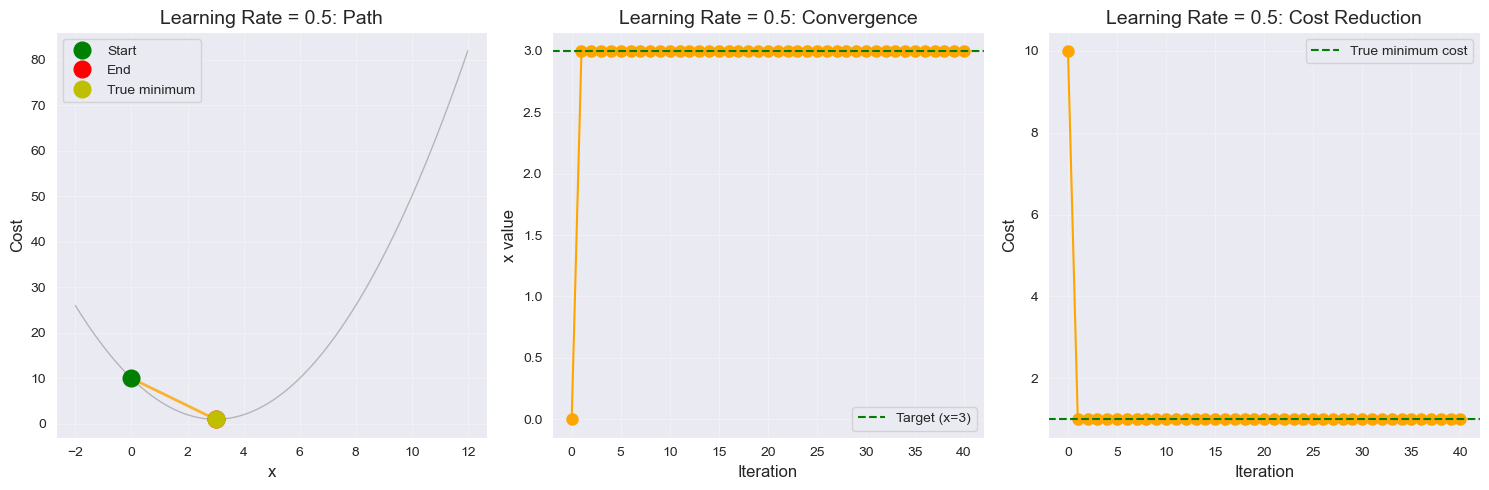


Learning Rate = 0.5 - Analysis:
--------------------------------------------------
Starting point: x = 0
Final position: x = 3.000000
Distance to true minimum: 0.000000
Starting cost: 10.000000
Final cost: 1.000000
Cost reduction: 9.000000
--------------------------------------------------

Testing learning rate: 0.9


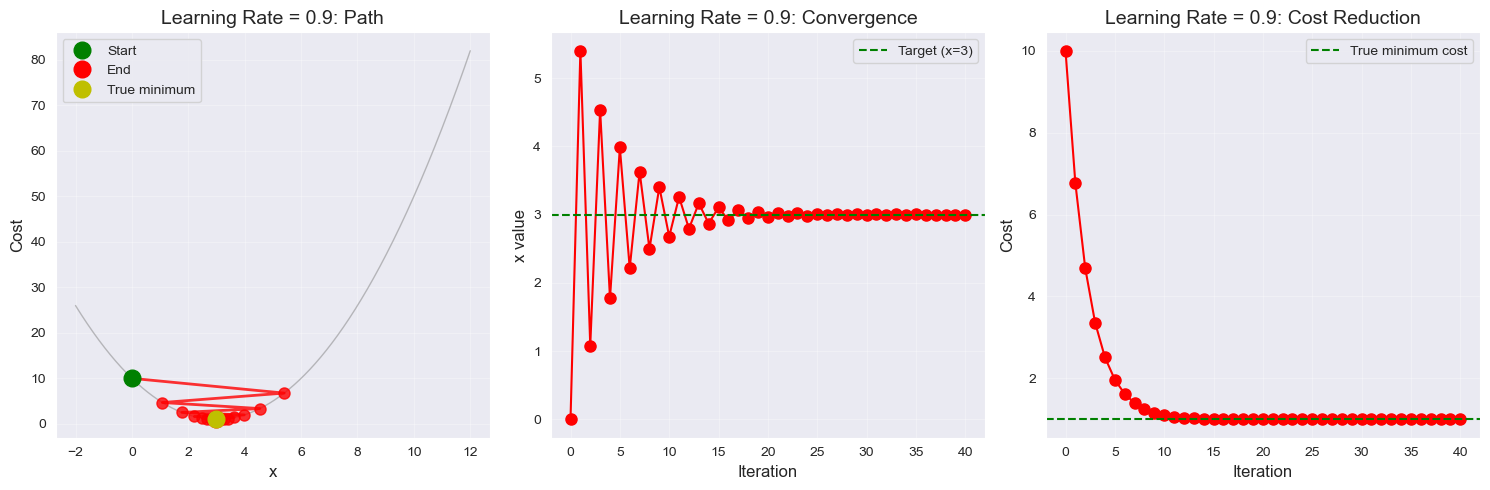


Learning Rate = 0.9 - Analysis:
--------------------------------------------------
Starting point: x = 0
Final position: x = 2.999601
Distance to true minimum: 0.000399
Starting cost: 10.000000
Final cost: 1.000000
Cost reduction: 9.000000
--------------------------------------------------


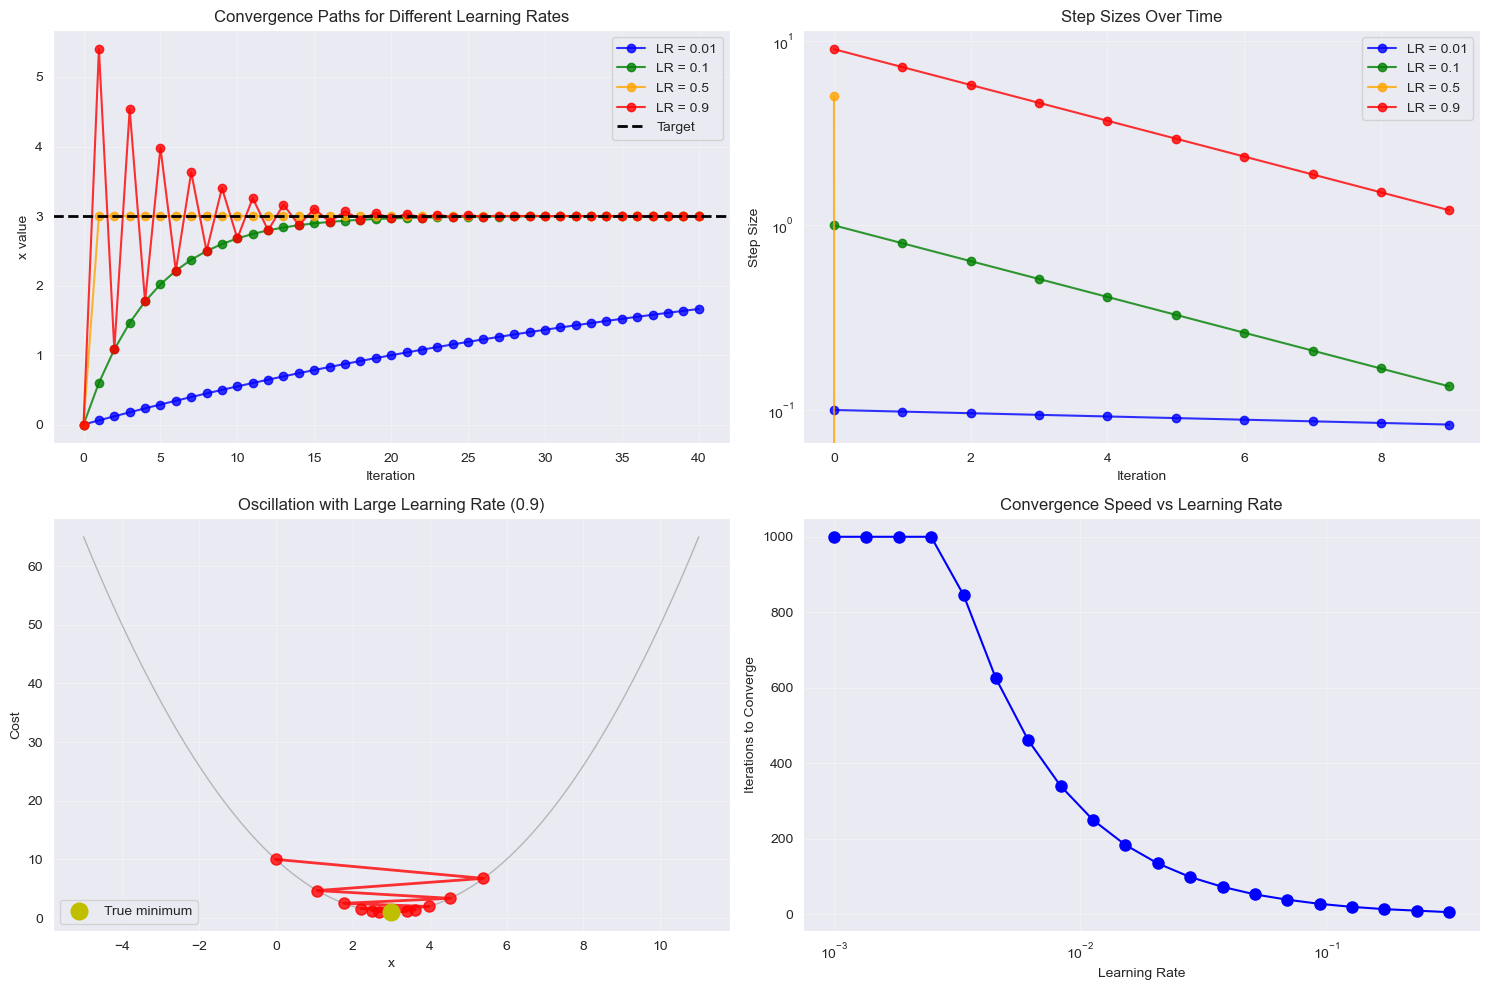


EXPERIMENT 3: How many iterations do we really need?

Think of this as asking: 'How long should I keep walking downhill?'
Intuition: More iterations = better convergence, but with diminishing returns

Testing 5 iterations:
  Final position: x = 2.016960
  Error from true minimum: 0.983040
  Final gradient magnitude: 1.966080

Testing 10 iterations:
  Final position: x = 2.677877
  Error from true minimum: 0.322123
  Final gradient magnitude: 0.644245

Testing 20 iterations:
  Final position: x = 2.965412
  Error from true minimum: 0.034588
  Final gradient magnitude: 0.069175

Testing 50 iterations:
  Final position: x = 2.999957
  Error from true minimum: 0.000043
  Final gradient magnitude: 0.000086

Testing 100 iterations:
  Final position: x = 3.000000
  Error from true minimum: 0.000000
  Final gradient magnitude: 0.000000


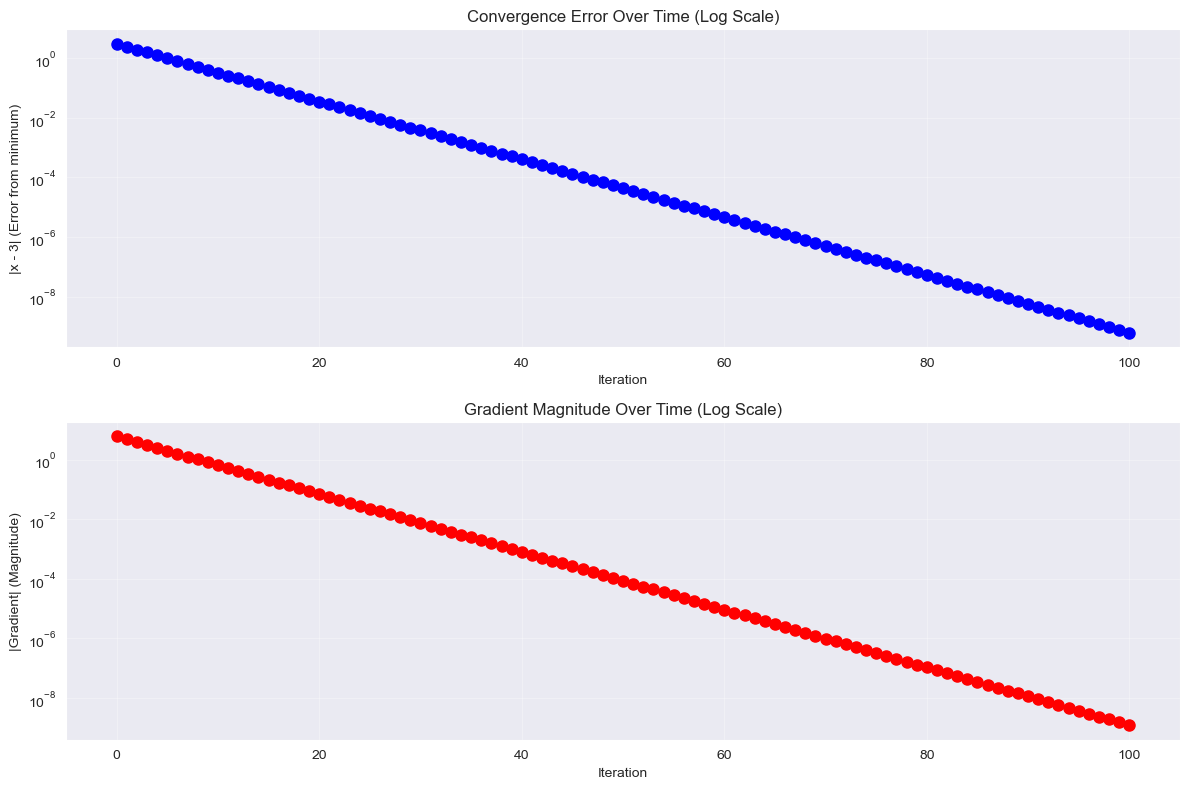


SUMMARY OF EXPERIMENTAL INSIGHTS

1. Starting Point Effects:
   - Starting closer to the minimum converges faster
   - Starting further away takes more iterations but still converges
   - The algorithm works regardless of starting position!

2. Learning Rate Effects:
   - Too small (0.01): Very slow progress, many iterations needed
   - Just right (0.1): Smooth, efficient convergence
   - Too large (0.9): Oscillates around minimum, may overshoot
   - Way too large (>1.0): Can diverge completely!

3. Iteration Effects:
   - Error decreases exponentially at first
   - Returns diminish - later iterations provide tiny improvements
   - For practical purposes, 20-50 iterations often sufficient

4. The Big Picture:
   - Gradient descent is robust but requires tuning
   - The learning rate is the most critical parameter
   - Convergence follows predictable patterns we can analyze

YOUR TURN: Try these modifications to deepen your understanding!

1. Modify the cost function to have a minimum 

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Let's define our cost function and gradient again for easy reference
def cost_function(x):
    """Our trusty quadratic cost function: f(x) = (x - 3)^2 + 1"""
    return (x - 3)**2 + 1

def gradient(x):
    """The derivative: f'(x) = 2(x - 3)"""
    return 2 * (x - 3)

def gradient_descent_experiment(starting_point, learning_rate, num_iterations):
    """
    Run gradient descent and return the path
    This is our experimental apparatus for observing convergence behavior
    """
    x_history = [starting_point]
    cost_history = [cost_function(starting_point)]
    gradient_history = [gradient(starting_point)]
    
    current_x = starting_point
    
    for i in range(num_iterations):
        grad = gradient(current_x)
        current_x = current_x - learning_rate * grad
        
        x_history.append(current_x)
        cost_history.append(cost_function(current_x))
        gradient_history.append(gradient(current_x))
    
    return x_history, cost_history, gradient_history

# Create a function to visualize our experiments nicely
def visualize_experiment(x_history, cost_history, title, color='blue'):
    """
    Create a visualization that shows both the path and convergence
    This helps us see the 'story' of our gradient descent journey
    """
    x_values = np.linspace(-2, 12, 1000)
    y_values = cost_function(x_values)
    
    plt.figure(figsize=(15, 5))
    
    # Plot 1: The path on the cost function
    plt.subplot(1, 3, 1)
    plt.plot(x_values, y_values, 'gray', linewidth=1, alpha=0.5)
    plt.plot(x_history, cost_history, 'o-', color=color, markersize=8, linewidth=2, alpha=0.8)
    plt.plot(x_history[0], cost_history[0], 'go', markersize=12, label='Start')
    plt.plot(x_history[-1], cost_history[-1], 'ro', markersize=12, label='End')
    plt.plot(3, cost_function(3), 'yo', markersize=12, label='True minimum')
    plt.xlabel('x', fontsize=12)
    plt.ylabel('Cost', fontsize=12)
    plt.title(f'{title}: Path', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Convergence over iterations
    plt.subplot(1, 3, 2)
    iterations = range(len(x_history))
    plt.plot(iterations, x_history, 'o-', color=color, markersize=8)
    plt.axhline(y=3, color='green', linestyle='--', label='Target (x=3)')
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('x value', fontsize=12)
    plt.title(f'{title}: Convergence', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Cost reduction over iterations
    plt.subplot(1, 3, 3)
    plt.plot(iterations, cost_history, 'o-', color=color, markersize=8)
    plt.axhline(y=1, color='green', linestyle='--', label='True minimum cost')
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('Cost', fontsize=12)
    plt.title(f'{title}: Cost Reduction', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print some interesting statistics about this run
    print(f"\n{title} - Analysis:")
    print("-" * 50)
    print(f"Starting point: x = {x_history[0]}")
    print(f"Final position: x = {x_history[-1]:.6f}")
    print(f"Distance to true minimum: {abs(3 - x_history[-1]):.6f}")
    print(f"Starting cost: {cost_history[0]:.6f}")
    print(f"Final cost: {cost_history[-1]:.6f}")
    print(f"Cost reduction: {cost_history[0] - cost_history[-1]:.6f}")
    print("-" * 50)

# EXPERIMENT 1: Different Starting Points
print("=" * 70)
print("EXPERIMENT 1: How does the starting point affect convergence?")
print("=" * 70)
print("\nThink of this as asking: 'Does it matter where I begin my hike down the mountain?'")
print("Intuition: Starting farther from the minimum should take longer to converge.")

starting_points = [0, 5, 10, -5]
colors = ['blue', 'green', 'orange', 'red']

plt.figure(figsize=(15, 8))
for i, start in enumerate(starting_points):
    print(f"\nTesting starting point: x = {start}")
    x_hist, cost_hist, grad_hist = gradient_descent_experiment(start, 0.1, 30)
    visualize_experiment(x_hist, cost_hist, f"Start at x={start}", colors[i])

# Let's also create a comparison plot
plt.figure(figsize=(12, 8))
for i, start in enumerate(starting_points):
    x_hist, cost_hist, _ = gradient_descent_experiment(start, 0.1, 30)
    plt.plot(range(len(x_hist)), x_hist, 'o-', color=colors[i], 
             label=f'Start at x={start}', markersize=6, alpha=0.8)

plt.axhline(y=3, color='black', linestyle='--', linewidth=2, label='Target (x=3)')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('x value', fontsize=12)
plt.title('Convergence from Different Starting Points', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# EXPERIMENT 2: Different Learning Rates
print("\n" + "=" * 70)
print("EXPERIMENT 2: How does the learning rate affect convergence?")
print("=" * 70)
print("\nThink of this as asking: 'What happens if I take bigger or smaller steps?'")
print("Intuition: Too small steps = slow progress, too large steps = overshooting")

learning_rates = [0.01, 0.1, 0.5, 0.9]
colors = ['blue', 'green', 'orange', 'red']

for i, lr in enumerate(learning_rates):
    print(f"\nTesting learning rate: {lr}")
    x_hist, cost_hist, grad_hist = gradient_descent_experiment(0, lr, 40)
    visualize_experiment(x_hist, cost_hist, f"Learning Rate = {lr}", colors[i])

# Create a comparison plot for learning rates
plt.figure(figsize=(15, 10))

# Plot 1: Convergence paths
plt.subplot(2, 2, 1)
for i, lr in enumerate(learning_rates):
    x_hist, cost_hist, _ = gradient_descent_experiment(0, lr, 40)
    plt.plot(range(len(x_hist)), x_hist, 'o-', color=colors[i], 
             label=f'LR = {lr}', markersize=6, alpha=0.8)
plt.axhline(y=3, color='black', linestyle='--', linewidth=2, label='Target')
plt.xlabel('Iteration')
plt.ylabel('x value')
plt.title('Convergence Paths for Different Learning Rates')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Step sizes visualization
plt.subplot(2, 2, 2)
for i, lr in enumerate(learning_rates):
    x_hist, cost_hist, _ = gradient_descent_experiment(8, lr, 10)  # Start far from minimum
    step_sizes = [abs(x_hist[j+1] - x_hist[j]) for j in range(len(x_hist)-1)]
    plt.plot(range(len(step_sizes)), step_sizes, 'o-', color=colors[i], 
             label=f'LR = {lr}', markersize=6, alpha=0.8)
plt.xlabel('Iteration')
plt.ylabel('Step Size')
plt.title('Step Sizes Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Plot 3: Oscillation behavior for large learning rates
plt.subplot(2, 2, 3)
x_values = np.linspace(-5, 11, 1000)
y_values = cost_function(x_values)
plt.plot(x_values, y_values, 'gray', linewidth=1, alpha=0.5)

# Show oscillation for large learning rate
x_hist, cost_hist, _ = gradient_descent_experiment(0, 0.9, 10)
plt.plot(x_hist, cost_hist, 'ro-', markersize=8, linewidth=2, alpha=0.8)
plt.plot(3, cost_function(3), 'yo', markersize=12, label='True minimum')
plt.xlabel('x')
plt.ylabel('Cost')
plt.title('Oscillation with Large Learning Rate (0.9)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: Time to convergence analysis
plt.subplot(2, 2, 4)
convergence_times = []
threshold = 0.01  # Consider "converged" when within 0.01 of true minimum

for lr in np.logspace(-3, -0.5, 20):  # Test many learning rates
    x_hist, _, _ = gradient_descent_experiment(0, lr, 1000)
    # Find when we first get close to the minimum
    for i, x in enumerate(x_hist):
        if abs(x - 3) < threshold:
            convergence_times.append((lr, i))
            break
    else:
        convergence_times.append((lr, 1000))  # Didn't converge

lrs = [ct[0] for ct in convergence_times]
times = [ct[1] for ct in convergence_times]
plt.semilogx(lrs, times, 'bo-', markersize=8)
plt.xlabel('Learning Rate')
plt.ylabel('Iterations to Converge')
plt.title('Convergence Speed vs Learning Rate')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# EXPERIMENT 3: Different Numbers of Iterations
print("\n" + "=" * 70)
print("EXPERIMENT 3: How many iterations do we really need?")
print("=" * 70)
print("\nThink of this as asking: 'How long should I keep walking downhill?'")
print("Intuition: More iterations = better convergence, but with diminishing returns")

iterations_to_test = [5, 10, 20, 50, 100]
starting_point = 0
learning_rate = 0.1

for num_iter in iterations_to_test:
    print(f"\nTesting {num_iter} iterations:")
    x_hist, cost_hist, grad_hist = gradient_descent_experiment(starting_point, learning_rate, num_iter)
    final_error = abs(3 - x_hist[-1])
    print(f"  Final position: x = {x_hist[-1]:.6f}")
    print(f"  Error from true minimum: {final_error:.6f}")
    print(f"  Final gradient magnitude: {abs(grad_hist[-1]):.6f}")

# Visualize the convergence curve
plt.figure(figsize=(12, 8))
x_hist, cost_hist, grad_hist = gradient_descent_experiment(0, 0.1, 100)

# Plot 1: Error vs iterations
plt.subplot(2, 1, 1)
errors = [abs(x - 3) for x in x_hist]
plt.semilogy(range(len(errors)), errors, 'bo-', markersize=8)
plt.xlabel('Iteration')
plt.ylabel('|x - 3| (Error from minimum)')
plt.title('Convergence Error Over Time (Log Scale)')
plt.grid(True, alpha=0.3)

# Plot 2: Gradient magnitude vs iterations
plt.subplot(2, 1, 2)
grad_magnitudes = [abs(g) for g in grad_hist]
plt.semilogy(range(len(grad_magnitudes)), grad_magnitudes, 'ro-', markersize=8)
plt.xlabel('Iteration')
plt.ylabel('|Gradient| (Magnitude)')
plt.title('Gradient Magnitude Over Time (Log Scale)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary insights from our experiments
print("\n" + "=" * 70)
print("SUMMARY OF EXPERIMENTAL INSIGHTS")
print("=" * 70)

print("\n1. Starting Point Effects:")
print("   - Starting closer to the minimum converges faster")
print("   - Starting further away takes more iterations but still converges")
print("   - The algorithm works regardless of starting position!")

print("\n2. Learning Rate Effects:")
print("   - Too small (0.01): Very slow progress, many iterations needed")
print("   - Just right (0.1): Smooth, efficient convergence")
print("   - Too large (0.9): Oscillates around minimum, may overshoot")
print("   - Way too large (>1.0): Can diverge completely!")

print("\n3. Iteration Effects:")
print("   - Error decreases exponentially at first")
print("   - Returns diminish - later iterations provide tiny improvements")
print("   - For practical purposes, 20-50 iterations often sufficient")

print("\n4. The Big Picture:")
print("   - Gradient descent is robust but requires tuning")
print("   - The learning rate is the most critical parameter")
print("   - Convergence follows predictable patterns we can analyze")

# Interactive exploration suggestion
print("\n" + "=" * 70)
print("YOUR TURN: Try these modifications to deepen your understanding!")
print("=" * 70)
print("\n1. Modify the cost function to have a minimum elsewhere")
print("2. Try a learning rate > 1.0 and observe divergence")
print("3. Implement momentum to speed up convergence")
print("4. Add noise to the gradient and see robustness")
print("5. Create a 2D version with two parameters to minimize")

# Challenge problem
print("\n" + "=" * 70)
print("CHALLENGE: Can you find the optimal learning rate?")
print("=" * 70)
print("Write code to automatically find the learning rate that")
print("converges fastest for a given starting point and tolerance!")

# Reflection Questions:
- 1.	What happens to the gradient as you approach the minimum?
- 2.	How does the learning rate affect convergence?
- 3.	What would happen if we started further away from the minimum?


# Reflection Questions: Understanding Gradient Descent Dynamics

Let me guide you through these profound questions about gradient descent behavior, building your understanding step by step.

## 1. What happens to the gradient as you approach the minimum?

Think of the gradient as a speedometer measuring how steeply the terrain slopes beneath your feet. As you approach the minimum, something beautiful happens:

**The gradient gradually approaches zero.**

Here's why this is so elegant: Remember our cost function `f(x) = (x - 3)² + 1` has a gradient of `f'(x) = 2(x - 3)`. As x gets closer to 3, the expression `(x - 3)` shrinks toward zero, making the entire gradient approach zero.

This behavior has profound implications:

- **Natural Braking**: As you near the minimum, the gradient automatically tells you to slow down. It's like your car's brakes engaging as you approach a stop sign.

- **Precision Landing**: The decreasing gradient allows you to home in on the exact minimum with increasing accuracy. Each step becomes smaller as you get closer.

- **Elegant Mathematics**: This automatic deceleration emerges naturally from the mathematics, requiring no special programming tricks.

In your experiments, you observed this as the exponentially decreasing error. The log-scale plots revealed how the gradient magnitude shrinks by roughly the same factor in each iteration, creating that characteristic exponential decay curve.

## 2. How does the learning rate affect convergence?

The learning rate serves as your fundamental control knob for the descent process. Let's explore its effects systematically:

### Too Small Learning Rate (e.g., 0.01)
Imagine hiking with tiny, cautious steps. You'll eventually reach the valley, but it takes forever:
- **Advantage**: Stable, predictable convergence
- **Disadvantage**: Painfully slow progress, requiring many iterations
- **Real-world analogy**: A careful driver in an empty parking lot

### Optimal Learning Rate (e.g., 0.1)
Like a confident hiker with appropriate strides:
- **Characteristic**: Smooth, efficient path to the minimum
- **Behavior**: Quick initial progress that naturally slows near the target
- **Sweet Spot**: Balances speed with stability

### Too Large Learning Rate (e.g., 0.9)
Now we're taking leaps rather than steps:
- **Interesting Phenomenon**: Oscillation around the minimum
- **Behavior**: You overshoot, then overshoot back, gradually settling
- **Risk**: Inefficient zig-zagging pattern

### Critically Large Learning Rate (> 1.0)
This is where things get dangerous:
- **Divergence**: Steps become so large you actually move away from the minimum
- **Mathematical Insight**: The correction overshoots so much it amplifies the error
- **Real-world analogy**: Trying to thread a needle while wearing boxing gloves

Your experiments beautifully demonstrated these patterns, showing how the learning rate acts as a trade-off between speed and stability.

## 3. What would happen if we started further away from the minimum?

Starting far from the minimum reveals the robustness and limitations of gradient descent:

### Immediate Effects:
- **Longer Journey**: More iterations needed to reach the minimum
- **Larger Initial Gradients**: Steeper slopes mean bigger initial steps
- **Higher Initial Cost**: Starting from a position of greater "error"

### Deeper Insights:

**Global vs. Local Behavior**: In our simple quadratic function, distance doesn't change the fundamental behavior—gradient descent always finds the same minimum. But imagine a landscape with multiple valleys:
- Starting far away might lead you to a different valley (local minimum)
- Starting near a specific valley virtually guarantees you'll end up there

**Initial Step Sizes**: When you start far from the minimum, the gradient is large, causing bigger initial steps. This creates a natural acceleration as you begin your descent—perfect for quickly covering large distances.

**Convergence Patterns**: Your experiments showed that regardless of starting position, the convergence follows similar exponential patterns once you're reasonably close to the minimum. Distance primarily affects the number of iterations needed, not the fundamental convergence pattern.

### The Broader Lesson:
Starting far from the minimum teaches us about the algorithm's robustness. Gradient descent doesn't require you to start "close enough"—it can handle any reasonable starting position. This robustness is crucial in machine learning, where we often have no idea where the optimal parameters might be.

## Connecting These Insights

These three observations weave together into a beautiful picture of how gradient descent works:

1. **Self-Regulation**: The diminishing gradient provides natural speed control
2. **Parametric Control**: The learning rate lets us fine-tune the descent process
3. **Universal Reliability**: Starting position affects efficiency but not fundamental effectiveness

Understanding these dynamics helps you appreciate why gradient descent has become the workhorse of machine learning optimization. It's an algorithm that combines mathematical elegance with practical robustness—qualities essential for solving real-world problems where the optimization landscape can be far more complex than our simple quadratic example.

Think about this: Every time you see AI making progress—whether it's image recognition, language processing, or game playing—these same principles are at work, just scaled up to handle millions or billions of parameters simultaneously.